In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import fetch_california_housing

In [5]:
boston=fetch_california_housing()
boston.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [7]:
## Lets check the description of the dataset
print(boston.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
print(boston.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [13]:
print(boston.target_names)

['MedHouseVal']


In [10]:
print(boston.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Preparing The Dataset

In [11]:
dataset=pd.DataFrame(boston.data,columns=boston.feature_names)

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
dataset['Price']=boston.target

In [15]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
## Summarizing The Stats of the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [17]:
## Check the missing Values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [18]:
### EXploratory Data Analysis
## Correlation
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


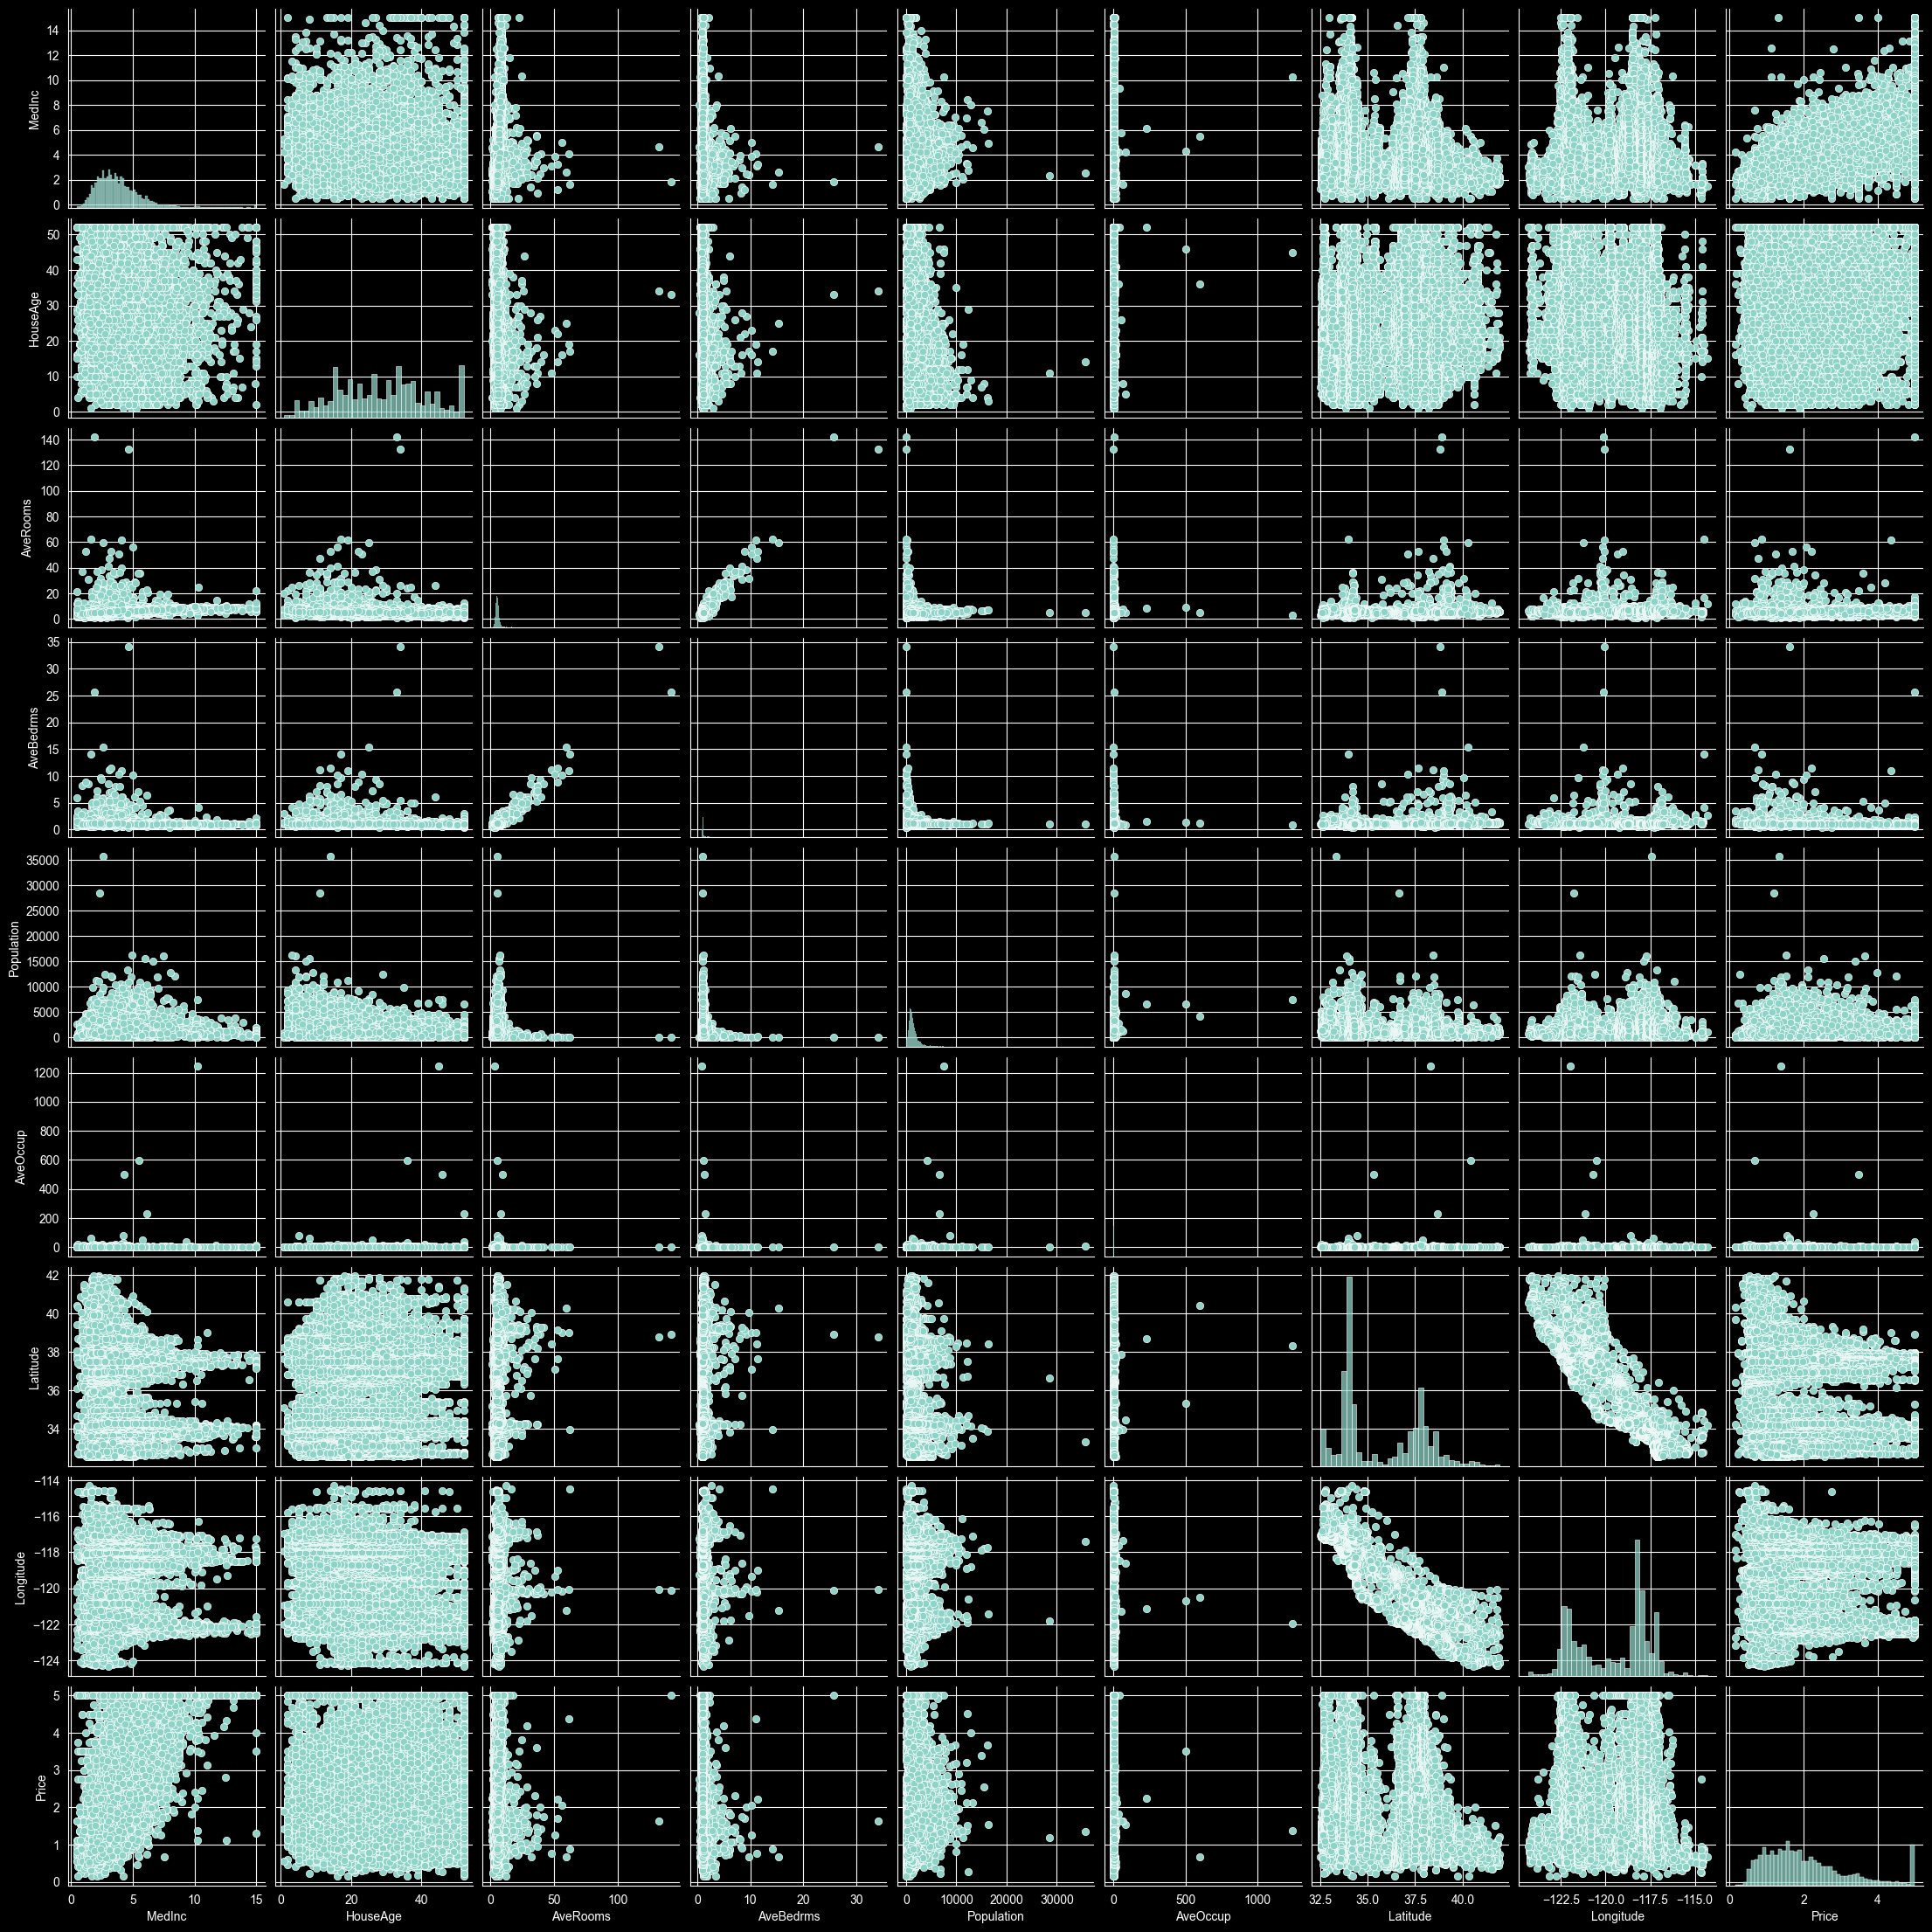

In [19]:

import seaborn as sns
sns.pairplot(dataset)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
18403  5.4741      24.0  6.587799   1.060181      4017.0  3.311624     37.24   
13405  1.9583       7.0  5.362805   1.442073      1064.0  3.243902     34.10   
9539   2.6058      40.0  3.885714   0.914286       785.0  4.485714     37.39   
8668   4.5817      30.0  4.146135   1.108696      1526.0  1.842995     33.82   
9019   8.0137       9.0  7.734673   1.041211     12873.0  3.274739     34.16   
...       ...       ...       ...        ...         ...       ...       ...   
19279  1.9458      26.0  4.709677   1.020161       937.0  3.778226     38.42   
12378  1.3801      25.0  4.737500   1.725000       604.0  2.516667     33.78   
16068  3.7361      48.0  5.754617   1.105541      1041.0  2.746702     37.75   
16563  5.0176      19.0  6.061538   0.956410      1264.0  3.241026     37.77   
12071  5.2898      25.0  6.722008   1.028958      3240.0  3.127413     33.86   

       Longitude    Price  
18403    -1

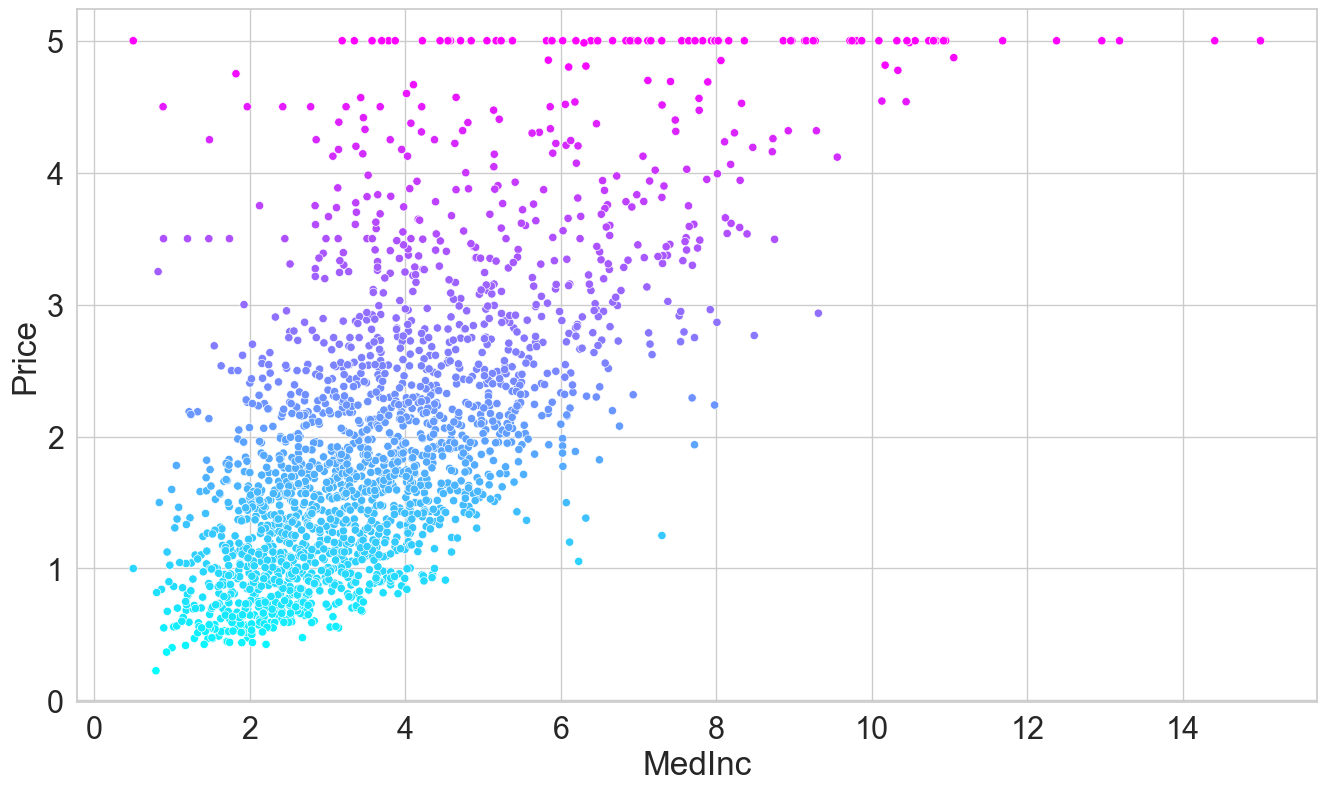

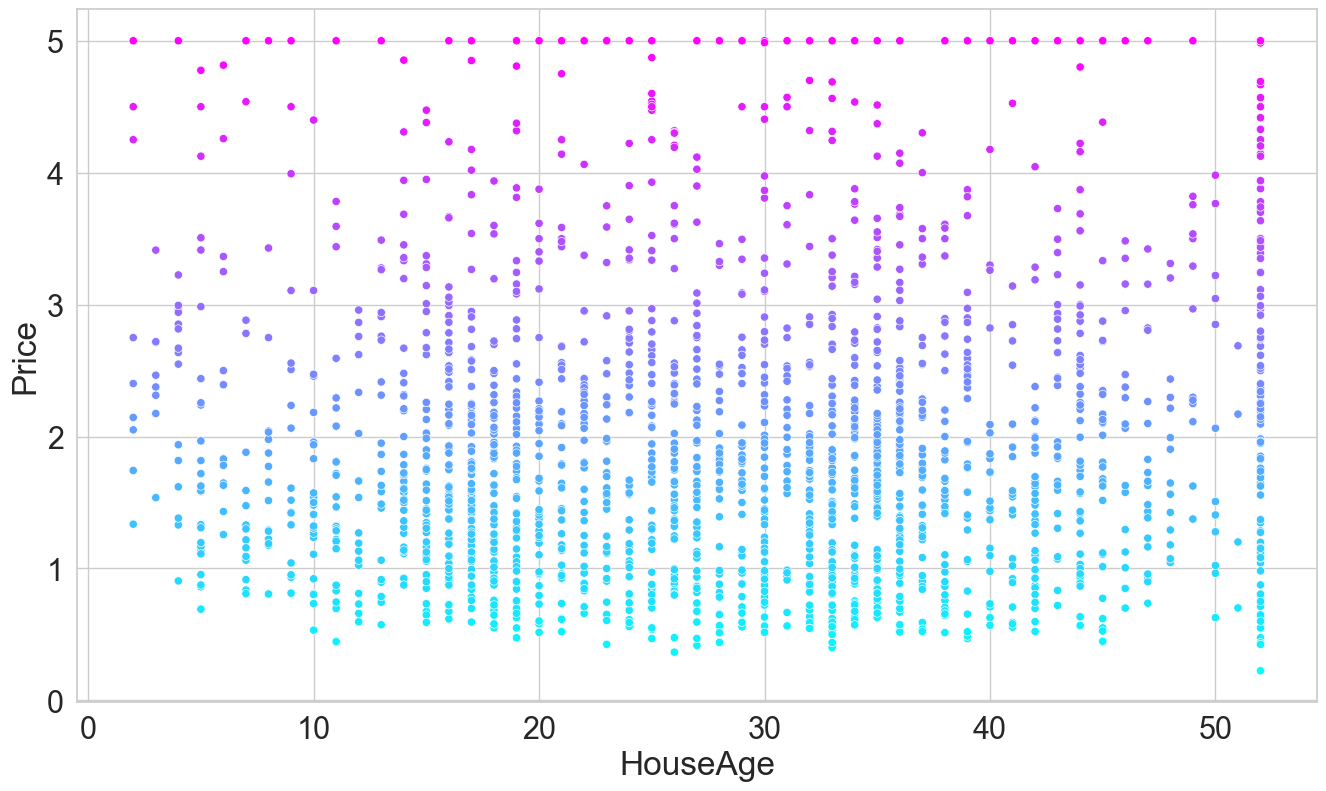

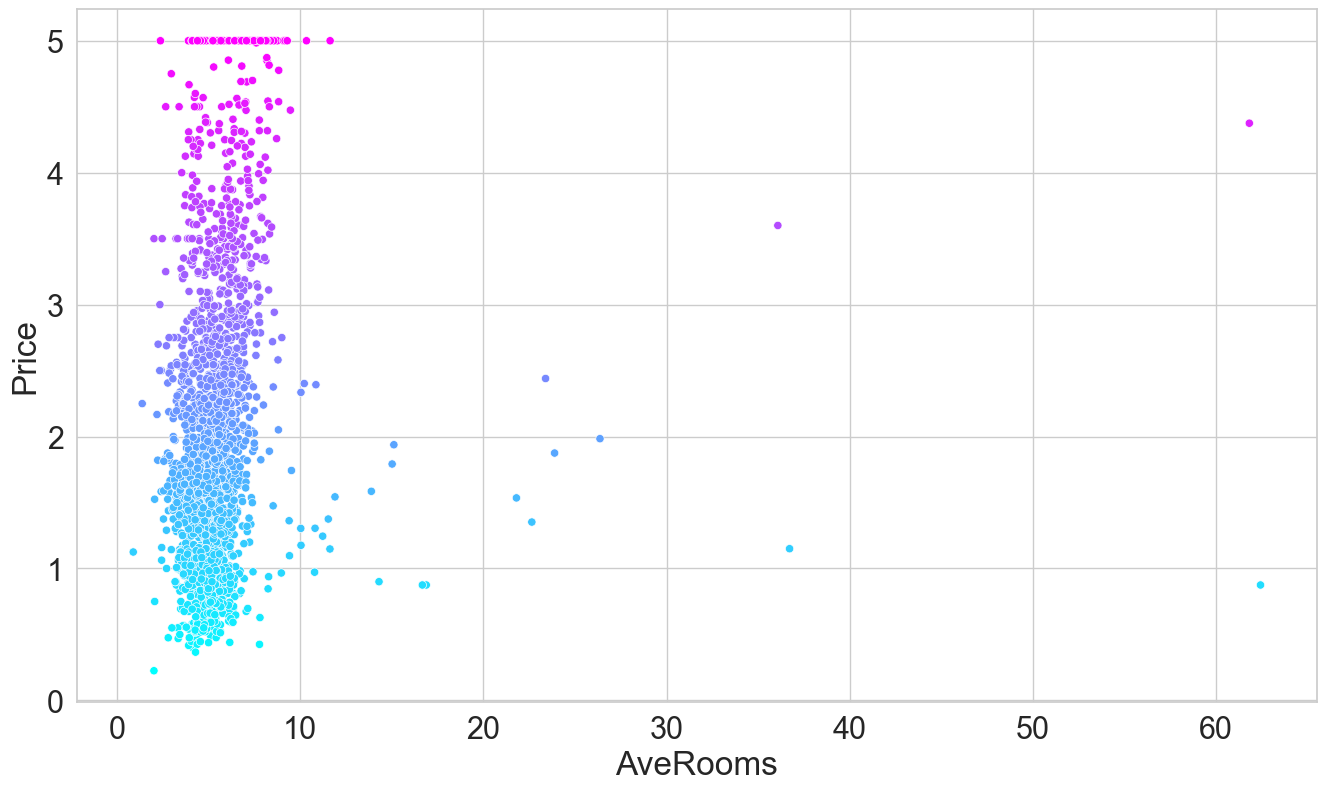

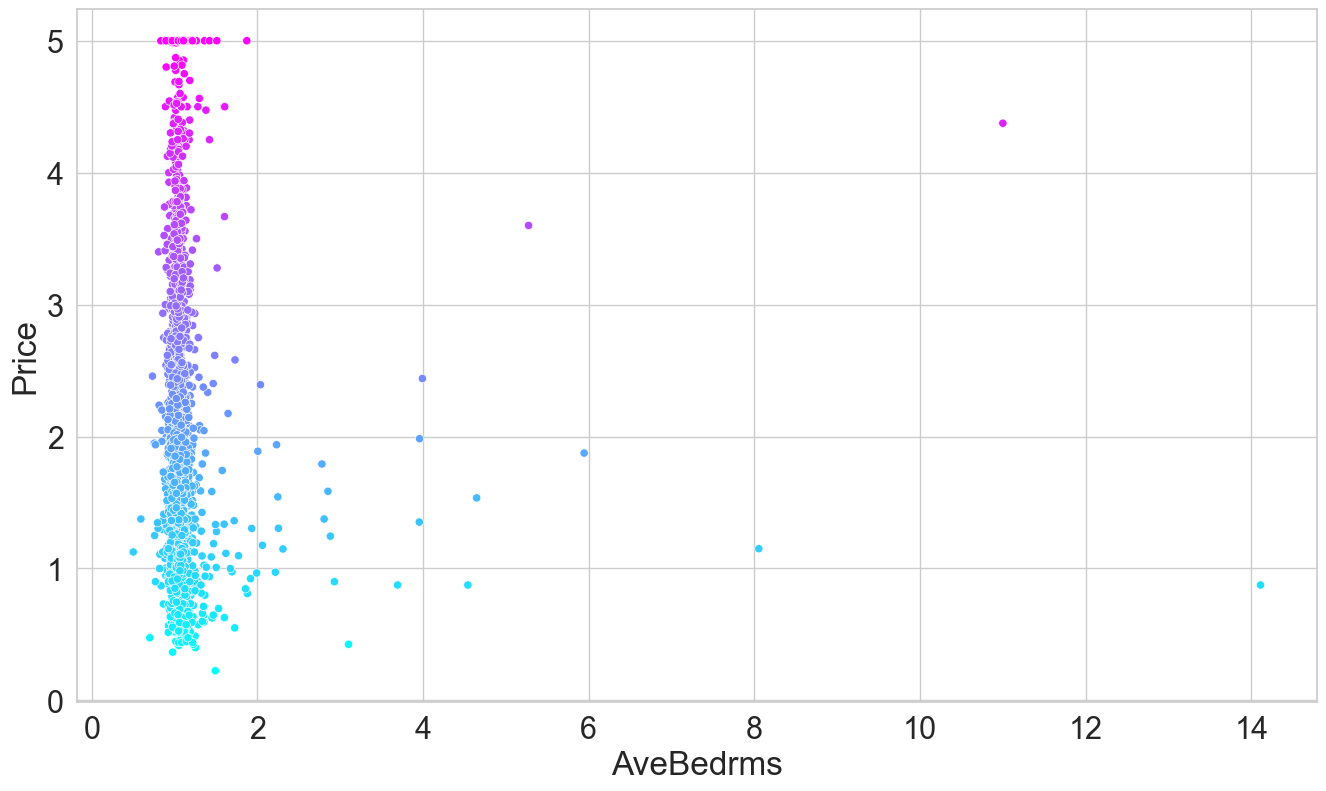

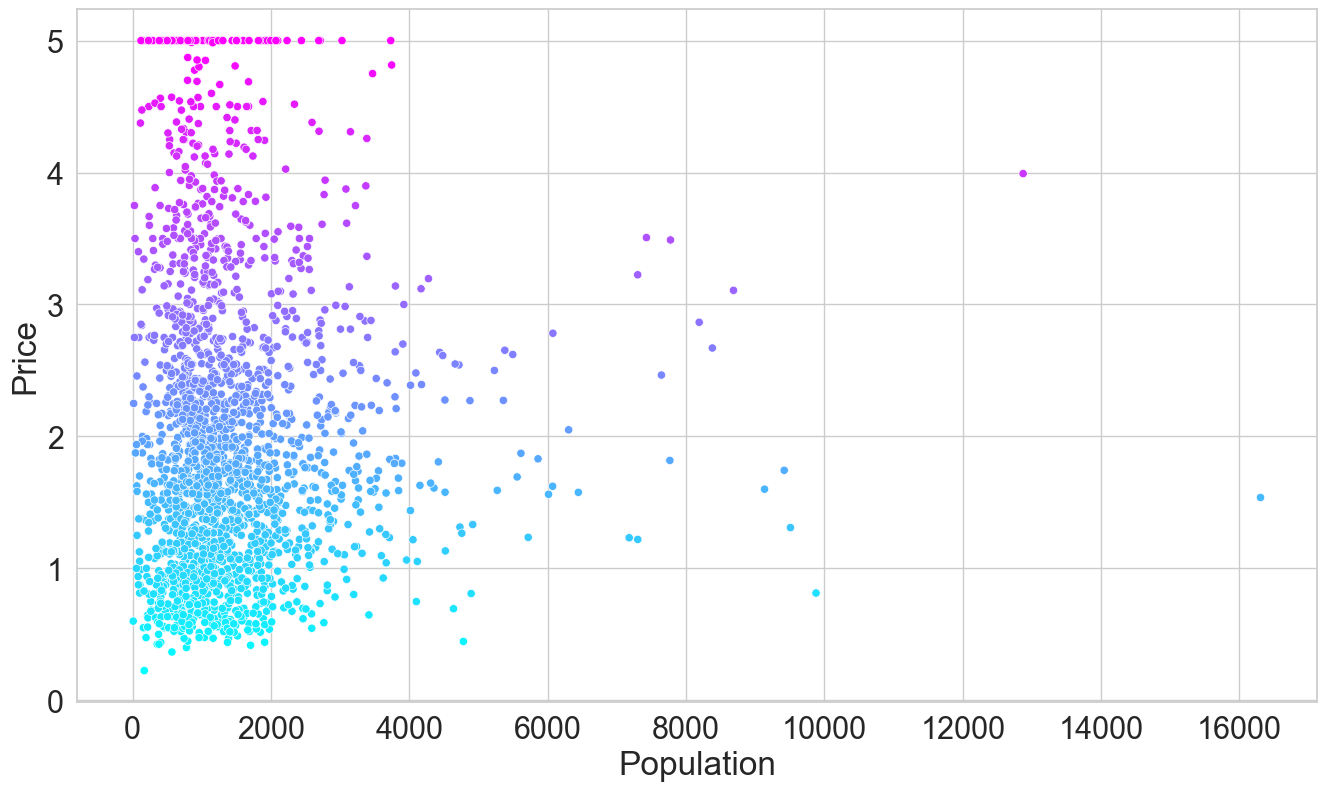

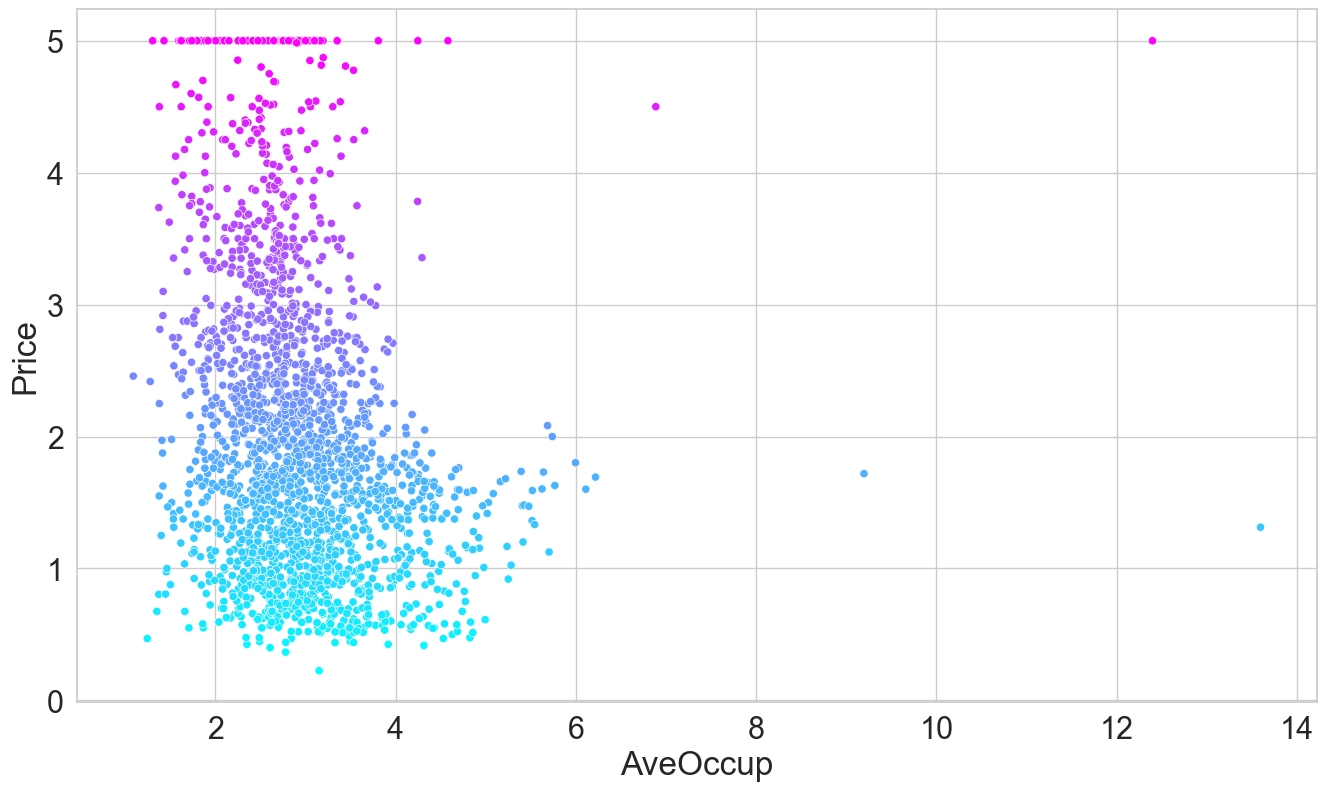

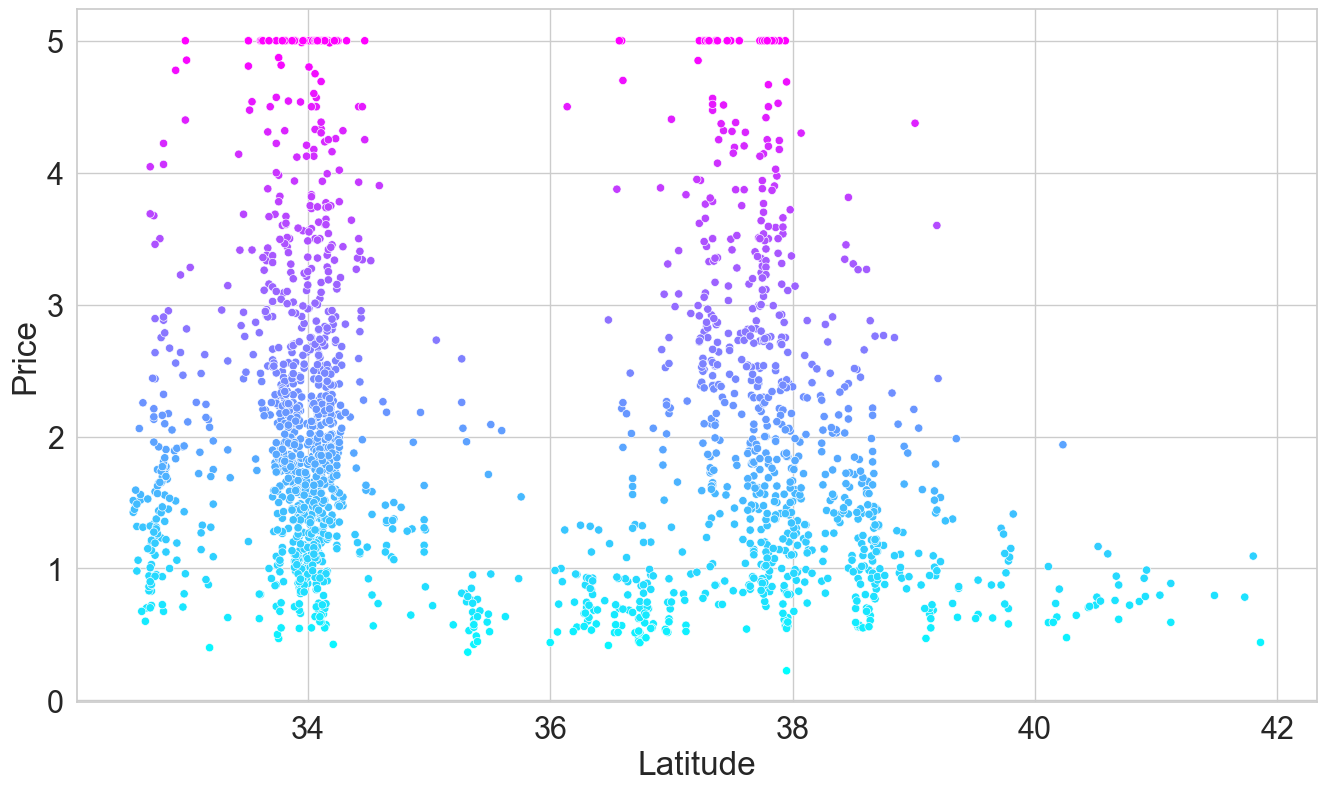

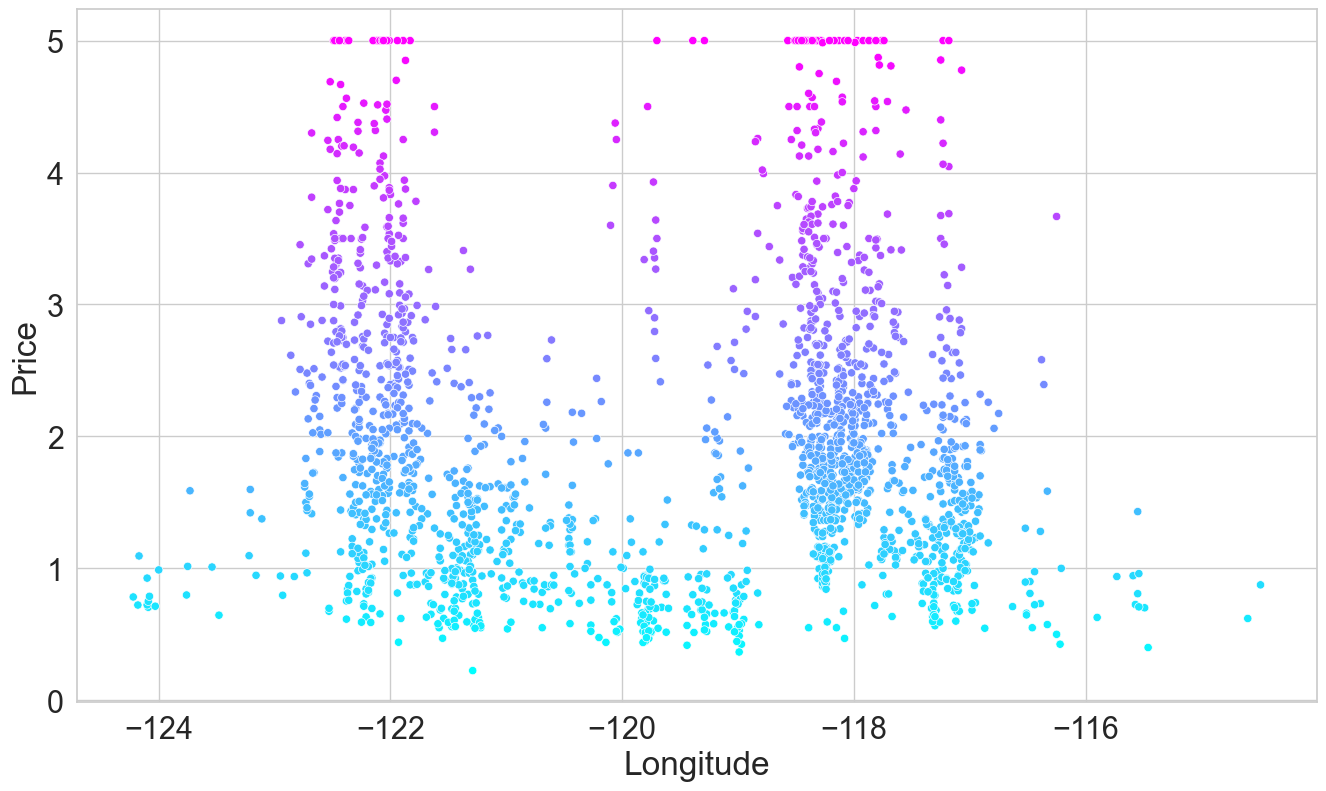

In [25]:
#using matplotlib for visualization
sample_df = dataset.sample(frac=0.1, random_state=17)
print(sample_df)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2)
sns.set_style('whitegrid')

for feature in boston.feature_names:
    plt.figure(figsize=(16, 9))
    sns.scatterplot(data=sample_df, x=feature,y='Price',
                    hue='Price', palette='cool', legend=False)

In [26]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [27]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [28]:
##Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [29]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [30]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [31]:
import pickle

pickle.dump(
    scaler,
    open('scaling.pkl', 'wb')
)

Model Training

In [32]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

### Prediction With Test Data
reg_pred=regression.predict(X_test)

In [35]:
from sklearn import metrics
print(f'The R2 score: {metrics.r2_score(y_test, reg_pred)}\n')
print(f'The MSE: {metrics.mean_squared_error(y_test, reg_pred)}')

The R2 score: 0.5957702326061665

The MSE: 0.5305677824766752


In [36]:
#choosing the best model
from sklearn.linear_model import ElasticNet, Lasso, Ridge
estimators = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

for name, model in estimators.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(name, score)

LinearRegression 0.5957702326061665
ElasticNet 0.2060087441777365
Lasso -3.930972139576383e-06
Ridge 0.5957885548359448


In [41]:
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd


# Les différents modèles
estimators = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1),
    'Lasso': Lasso(alpha=0.1),
    'Ridge': Ridge()
}


# Stocker les résultats
results = []


for name, model in estimators.items():

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Ajouter les résultats
    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })
    print(y_pred)


# Transformer en DataFrame
results_df = pd.DataFrame(results)

# Afficher
print(results_df)

[0.72604907 1.76743383 2.71092161 ... 2.07465531 1.57371395 1.82744133]
[1.13725237 1.61663882 2.19181821 ... 1.84719471 1.71847516 1.66891273]
[1.2205456  1.58340606 2.10916044 ... 1.83694644 1.81729865 1.67200076]
[0.72643939 1.76724055 2.71051564 ... 2.07445267 1.57387691 1.82728481]
              Model        R2       MAE       MSE      RMSE      MAPE
0  LinearRegression  0.595770  0.527247  0.530568  0.728401  0.317503
1        ElasticNet  0.527608  0.591207  0.620034  0.787422  0.373299
2             Lasso  0.493492  0.616494  0.664812  0.815360  0.395511
3             Ridge  0.595789  0.527243  0.530544  0.728384  0.317496


In [42]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
estimators = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}
# Stocker les résultats
results = []


for name, model in estimators.items():

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Ajouter les résultats
    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })
    print(y_pred)


# Transformer en DataFrame
results_df = pd.DataFrame(results)

# Afficher
print(results_df)


[0.72604907 1.76743383 2.71092161 ... 2.07465531 1.57371395 1.82744133]
[0.72643939 1.76724055 2.71051564 ... 2.07445267 1.57387691 1.82728481]
[0.50031333 0.75932667 4.8636697  ... 2.0525067  1.42357003 2.22868343]
[0.48144006 1.00722255 4.72103009 ... 2.1508174  1.35258129 2.02584447]
              Model        R2       MAE       MSE      RMSE      MAPE
0  LinearRegression  0.595770  0.527247  0.530568  0.728401  0.317503
1             Ridge  0.595789  0.527243  0.530544  0.728384  0.317496
2      RandomForest  0.807842  0.329195  0.252215  0.502210  0.189361
3  GradientBoosting  0.830053  0.317762  0.223062  0.472294  0.183523


In [43]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ==========================================
# 1. Définition des modèles
# ==========================================

estimators = {

    # Modèle linéaire
    "LinearRegression": LinearRegression(),

    # Régularisation L2
    "Ridge": Ridge(),

    # Random Forest
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    # Gradient Boosting
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    # XGBoost
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    # LightGBM
    "LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}


# ==========================================
# 2. Stocker les résultats
# ==========================================

results = []


# ==========================================
# 3. Entraîner et évaluer chaque modèle
# ==========================================

for name, model in estimators.items():

    print(f"\n===== {name} =====")

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation
    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    )

    # Stocker les résultats
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape
    })

    # Afficher les prédictions
    print("Predictions :")
    print(y_pred)


# ==========================================
# 4. Transformer les résultats en DataFrame
# ==========================================

results_df = pd.DataFrame(results)


# ==========================================
# 5. Afficher les résultats
# ==========================================

print("\n===== RESULTATS =====")
print(results_df)


===== LinearRegression =====
Predictions :
[0.72604907 1.76743383 2.71092161 ... 2.07465531 1.57371395 1.82744133]

===== Ridge =====
Predictions :
[0.72643939 1.76724055 2.71051564 ... 2.07445267 1.57387691 1.82728481]

===== RandomForest =====
Predictions :
[0.50031333 0.75932667 4.8636697  ... 2.0525067  1.42357003 2.22868343]

===== GradientBoosting =====
Predictions :
[0.48144006 1.00722255 4.72103009 ... 2.1508174  1.35258129 2.02584447]

===== XGBoost =====
Predictions :
[0.5281611  0.84560823 5.326035   ... 2.5588317  1.357912   2.178335  ]

===== LightGBM =====
Predictions :
[0.50374001 0.99589681 5.05096727 ... 2.32852576 1.42534835 2.13411444]

===== RESULTATS =====
              Model        R2       MAE       MSE      RMSE      MAPE
0  LinearRegression  0.595770  0.527247  0.530568  0.728401  0.317503
1             Ridge  0.595789  0.527243  0.530544  0.728384  0.317496
2      RandomForest  0.807842  0.329195  0.252215  0.502210  0.189361
3  GradientBoosting  0.830053  0.

C:\Users\TAKWA-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\TAKWA-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


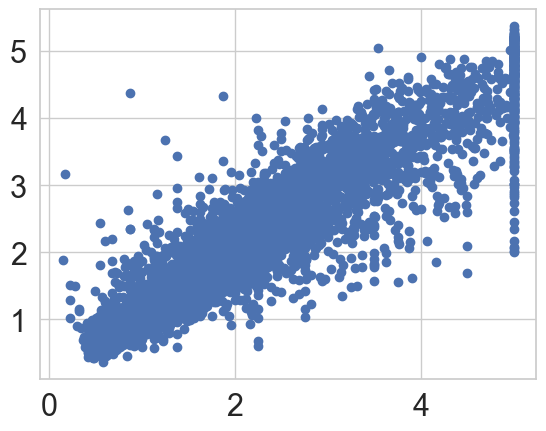

In [45]:
regression=LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
regression.fit(X_train,y_train)
## print the coefficients and the intercept
regression.get_params()
reg_pred=regression.predict(X_test)
reg_pred
plt.scatter(y_test,reg_pred)
## Residuals
residuals=y_test-reg_pred

In [46]:
import pickle
pickle.dump(regression,open('regmodel.pkl','wb'))
pickled_model=pickle.load(open('regmodel.pkl','rb'))
## Prediction
pickled_model.predict(scaler.transform(boston.data[0].reshape(1,-1)))


C:\Users\TAKWA-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\TAKWA-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([4.09217316])